#  Notebook 4 — Modelo con Mitigación de Sesgo
## HMDA New York 2024: Sesgo, Equidad y Explicabilidad en Hipotecas

**Autores:** Izan Cuesta Corbí · Dennis García Solera · Marcos Segurado Llopis · Jesús Cano Moya  
**Dataset:** Home Mortgage Disclosure Act (HMDA) — New York 2024 (CFPB)

---
> **Objetivo de este notebook:** Mitigar el sesgo demográfico del modelo LightGBM ganador mediante técnicas algorítmicas (*Fairlearn*). Evaluaremos el *trade-off* resultante entre rendimiento y equidad, y auditaremos con SHAP cómo se neutraliza la discriminación en las nuevas predicciones.

> `RANDOM_STATE = 42` fijado globalmente para reproducibilidad.

--- 

### Imports

In [55]:
import re
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score
)
import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

---
---

## Conjunto de Datos

NO MODIFICADO:

En este notebook hemos cargado los conjuntos de entrenamiento y test generados en el Notebook 1, ya preprocesados, imputados y escalados. Al partir de los mismos datos que el baseline, garantizamos que cualquier diferencia en los resultados sea atribuible exclusivamente al modelo utilizado y no al preprocesamiento.

---

### Carga y limpieza del dataset

NOTA: LIMPIEZA LIGHTGBM

In [16]:
def limpiar_columnas(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

In [22]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

train = limpiar_columnas(train)
test  = limpiar_columnas(test)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

train.head()

Train: (226665, 81)
Test:  (56667, 81)


,derived_msa_md,county_code,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose,loan_amount,...,derived_race_Black_or_African_American,derived_race_Free_Form_Text_Only,derived_race_Joint,derived_race_Native_Hawaiian_or_Other_Pacific_Islander,derived_race_Race_Not_Available,derived_race_White,derived_sex_Female,derived_sex_Joint,derived_sex_Male,derived_sex_Sex_Not_Available
0,-0.053043,-0.136364,0.0,0.0,9.666667,1.0,0.0,1.0,0.0,-0.030303,...,False,False,False,False,False,True,False,True,False,False
1,5.598696,0.772727,0.0,0.0,-0.333333,0.0,0.0,0.0,0.0,-0.303030,...,False,False,False,False,False,True,False,False,True,False
2,-1.898609,-1.318182,0.0,0.0,0.666667,1.0,0.0,0.0,0.0,-0.545455,...,False,False,False,False,False,True,False,True,False,False
3,0.414435,-0.227273,0.0,0.0,-0.333333,0.0,0.0,0.0,1.0,-0.272727,...,False,False,False,False,True,False,False,False,False,True
4,0.000000,0.363636,0.0,0.0,9.666667,0.0,0.0,0.0,1.0,0.696970,...,False,False,False,False,True,False,True,False,False,False


---
### Selección de Columnas

NO MODIFICADO: 

A diferencia del Notebook 2, en este caso hemos incluido todas las columnas disponibles como features, incluyendo los atributos sensibles (`derived_race_*`, `derived_sex_*`, `derived_ethnicity_*`). El objetivo es evaluar el comportamiento natural de los modelos de ensamble sin ninguna restricción, para identificar el sesgo inherente que introducen cuando tienen acceso a información demográfica.

In [26]:
SENSITIVE_COLS = [col for col in train.columns if 
                  col.startswith('derived_race_') or 
                  col.startswith('derived_sex_') or 
                  col.startswith('derived_ethnicity_')]

FEATURE_COLS = [col for col in train.columns if col != 'action_taken']

print(f"Nº de features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")
print(f"\nNº de features sensibles: {len(SENSITIVE_COLS)}")
print(f"Features: {SENSITIVE_COLS}")

Nº de features: 80
Features: ['derived_msa_md', 'county_code', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open_end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_term', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'income', 'debt_to_income_ratio', 'applicant_credit_score_type', 'co_applicant_credit_score_type', 'applicant_ethnicity_1', 'co_applicant_ethnicity_1', 'applicant_ethnicity_observed', 'co_applicant_ethnicity_observed', 'applicant_race_1', 'co_applicant_race_1', 'applicant_race_observed', 'co_applicant_race_observed', 'applicant_sex', 'co_applicant_sex', 'applicant_sex_observed', 'co_applicant_sex_observed', 'applicant_age', 'applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'aus_1

---
### Separación de Train/Test

In [25]:
X_train = train[FEATURE_COLS] # columnas que entran al modelo 
y_train = train['action_taken'] # columna que queremos predecir

X_test = test[FEATURE_COLS] 
y_test = test['action_taken']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (226665, 80)
X_test:  (56667, 80)


---
---

## Comparativa de Modelos

---
### Mejor Modelo: LightGBM

nota: modelo guardado esta ya entrenado (fit)

In [24]:
modelo = joblib.load('../models/lightgbm.pkl')

In [35]:
resultados_comparacion = []

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

resultados_comparacion.append({
    'Modelo': 'LightGBM Sesgado',
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'F1-Score': round(f1_score(y_test, y_pred), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
})

---

### Modelo con Mitigación de Sesgo

In [37]:
# Variable sensible principal a analizar
sensitive_feature_train = X_train['derived_race_White']
sensitive_feature_test  = X_test['derived_race_White']

mitigador = ExponentiatedGradient(
    estimator=modelo,                   # Nuestro LightGBM previamente optimizado
    constraints=EqualizedOdds(),
    sample_weight_name='sample_weight'  # Parámetro necesario para integrarlo con LightGBM
)

# Entrenamiento del modelo mitigado
mitigador.fit(X_train, y_train, sensitive_features=sensitive_feature_train)

# Nuevas predicciones "equitativas"
# Usamos _pmf_predict en lugar de predict_proba para modelos mitigados por Fairlearn
y_pred_mitigado = mitigador.predict(X_test)
y_prob_mitigado = mitigador._pmf_predict(X_test)[:, 1]

resultados_comparacion.append({
    'Modelo': 'LightGBM Mitigado',
    'Accuracy': round(accuracy_score(y_test, y_pred_mitigado), 4),
    'F1-Score': round(f1_score(y_test, y_pred_mitigado), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_mitigado), 4)
})

---
### Comparación de Rendimiento

**Tabla Comparativa**

In [38]:
comparativa_sesgo = pd.DataFrame(resultados_comparacion).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(comparativa_sesgo)

,Modelo,Accuracy,F1-Score,ROC-AUC
0,LightGBM Sesgado,0.8621,0.9116,0.8868
1,LightGBM Mitigado,0.8619,0.9115,0.7803


**Curvas ROC**

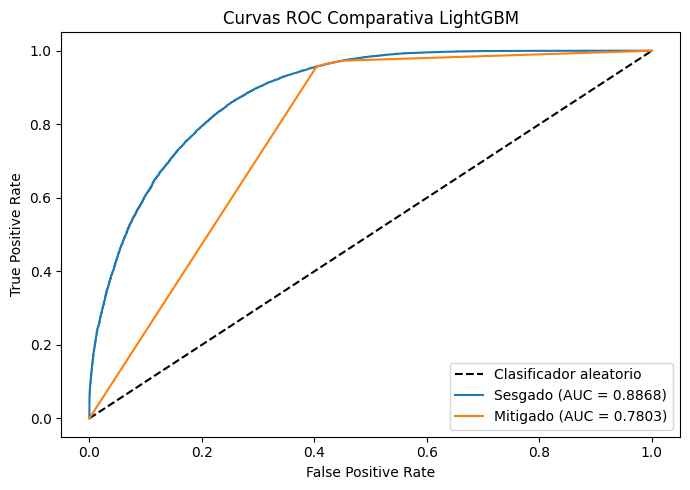

In [40]:
plt.figure(figsize=(7, 5))

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')

# Sesgado
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Sesgado (AUC = {auc_score:.4f})')

# Mitigado
fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_mitigado)
auc_score_m = roc_auc_score(y_test, y_prob_mitigado)
plt.plot(fpr_m, tpr_m, label=f'Mitigado (AUC = {auc_score_m:.4f})')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Comparativa LightGBM')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/images/curva_roc_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

**Matriz de Confusión**

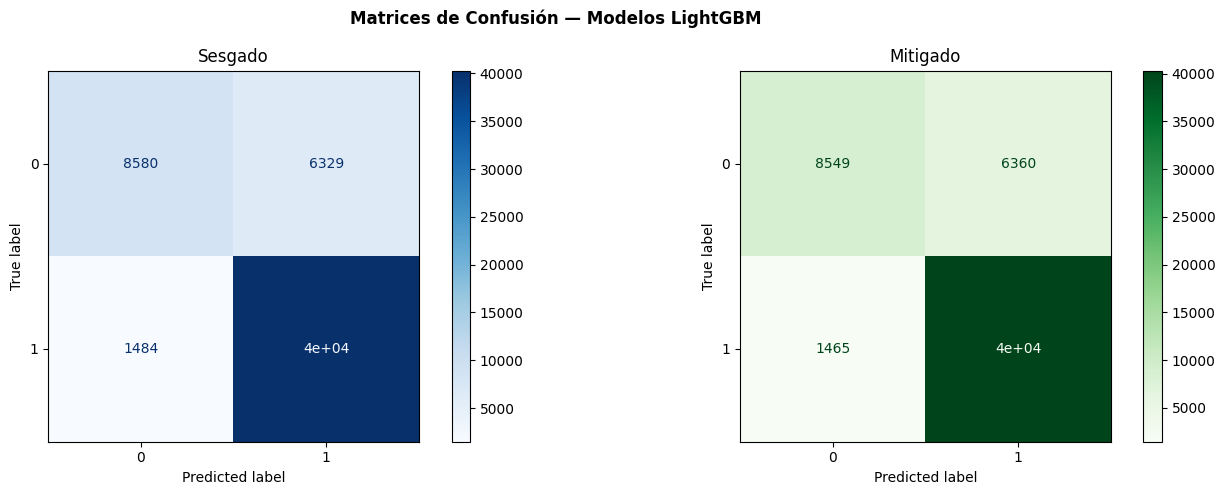

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrices de Confusión — Modelos LightGBM', fontweight='bold')

# Sesgado
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    ax=axes[0],
    colorbar=True,
    cmap='Blues'
)
axes[0].set_title("Sesgado")
axes[0].grid(False)

# Mitigado
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mitigado, 
    ax=axes[1],
    colorbar=True,
    cmap='Greens'
)
axes[1].set_title("Mitigado")
axes[1].grid(False)


plt.tight_layout()
plt.savefig('../outputs/images/matriz_confusion_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

---
---

## Fairness y Explicabilidad

---
### Análisis de Fairness

NO MODIFICADO:

Evaluamos si LightGBM, pese a su mayor capacidad predictiva, introduce más sesgo que el baseline al tener acceso a los atributos sensibles durante el entrenamiento. Calculamos las mismas métricas de Demographic Parity y Equalized Odds sobre los grupos de raza, sexo y etnia para poder comparar directamente con los resultados 
del Notebook 2.

In [46]:
sensitive_groups_test = test[SENSITIVE_COLS]

def fairness_report(y_true, y_pred, groups, sensitive_prefix):
    cols = [c for c in groups.columns if c.startswith(sensitive_prefix)]
    resultados = []
    for col in cols:
        mask = groups[col].reset_index(drop=True) == 1
        if mask.sum() < 50:
            continue
        yt = y_true.reset_index(drop=True)[mask]
        yp = pd.Series(y_pred)[mask]
        approval_rate = (yp == 1).mean()
        tp = ((yt == 1) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        nombre = col.replace(sensitive_prefix, '')
        resultados.append({
            'Grupo': nombre,
            'N': mask.sum(),
            'Approval Rate (DP)': round(approval_rate, 4),
            'TPR': round(tpr, 4),
            'FPR': round(fpr, 4)
        })
    return pd.DataFrame(resultados).sort_values('Approval Rate (DP)', ascending=False)

#### Fairness por raza

In [47]:
print("FAIRNESS — RAZA")
print("=" * 60)
df_raza = fairness_report(y_test, y_pred_mitigado, sensitive_groups_test, 'derived_race_')
print(df_raza.to_string(index=False))

FAIRNESS — RAZA
                                    Grupo     N  Approval Rate (DP)    TPR    FPR
                                    Joint   953              0.8909 0.9780 0.5140
                                    White 35847              0.8411 0.9637 0.4398
                                    Asian  5135              0.8407 0.9811 0.4115
                       Race_Not_Available  9695              0.8102 0.9686 0.4472
                Black_or_African_American  4493              0.7038 0.9463 0.3626
         American_Indian_or_Alaska_Native   249              0.6104 0.9308 0.2605
                 2_or_more_minority_races   141              0.6099 0.8904 0.3088
Native_Hawaiian_or_Other_Pacific_Islander   130              0.5615 0.9275 0.1475


NO MODIFICADO:

Los resultados por raza revelan que LightGBM amplía las disparidades respecto al baseline. Las personas blancas obtienen una tasa de aprobación del 85.25%, mientras que las personas negras o afroamericanas alcanzan el 66.86%, una brecha de más de 18 puntos porcentuales. Aunque el TPR de todos los grupos mejora respecto al baseline (el modelo identifica correctamente más aprobaciones reales en todos los grupos), la brecha en Approval Rate se mantiene, lo que indica que el sesgo no desaparece al aumentar la capacidad del modelo sino que se perpetúa. El grupo Native Hawaiian or Other Pacific Islander presenta la tasa más baja con un 51.54%, aunque su tamaño muestral reducido (N=130) limita la solidez estadística de este resultado.

#### Fairness por sexo

In [48]:
print("FAIRNESS — SEXO")
print("=" * 60)
df_sexo = fairness_report(y_test, y_pred_mitigado, sensitive_groups_test, 'derived_sex_')
print(df_sexo.to_string(index=False))

FAIRNESS — SEXO
            Grupo     N  Approval Rate (DP)    TPR    FPR
            Joint 18386              0.8859 0.9766 0.5073
Sex_Not_Available  4940              0.8423 0.9735 0.5065
             Male 19860              0.7899 0.9568 0.3957
           Female 13481              0.7801 0.9552 0.3736


NO MODIFICADO:

Los resultados por sexo muestran diferencias moderadas pero consistentes. Las solicitudes conjuntas (Joint) lideran con un 88.63% de aprobación, mientras que mujeres (78.06%) y hombres (79.16%) presentan tasas similares con apenas 1.1 puntos de diferencia. El TPR es alto en todos los grupos (>95%), lo que indica que el modelo identifica correctamente la mayoría de aprobaciones reales independientemente del sexo. La principal disparidad se observa en el FPR: Joint presenta un 51.01% frente al 37.51% de las mujeres, lo que sugiere que el modelo es más permisivo con las solicitudes conjuntas.

#### Fairness por etnia

In [49]:
print("FAIRNESS — ETNIA")
print("=" * 60)
df_etnia = fairness_report(y_test, y_pred_mitigado, sensitive_groups_test, 'derived_ethnicity_')
print(df_etnia.to_string(index=False))

FAIRNESS — ETNIA
                  Grupo     N  Approval Rate (DP)    TPR    FPR
 Not_Hispanic_or_Latino 41660              0.8367 0.9668 0.4373
                  Joint  1200              0.8367 0.9684 0.4099
Ethnicity_Not_Available  8891              0.8241 0.9714 0.4660
     Hispanic_or_Latino  4891              0.7056 0.9317 0.3132


NO MODIFICADO:

Los resultados por etnia muestran la brecha más reducida de los tres atributos sensibles analizados. Las personas no hispanas (83.92%) y las solicitudes conjuntas (84.00%) presentan tasas similares, mientras que las personas hispanas o latinas obtienen un 70.78%, una diferencia de 13 puntos porcentuales. El TPR de las personas hispanas (93.33%) es alto aunque inferior al de las no hispanas (96.85%), lo que indica que el modelo identifica correctamente la mayoría de sus aprobaciones reales pero con mayor margen de error. Esta brecha, aunque menor que la observada por raza, sigue siendo estadísticamente relevante con 4.891 instancias en el grupo minoritario.

#### Visualización

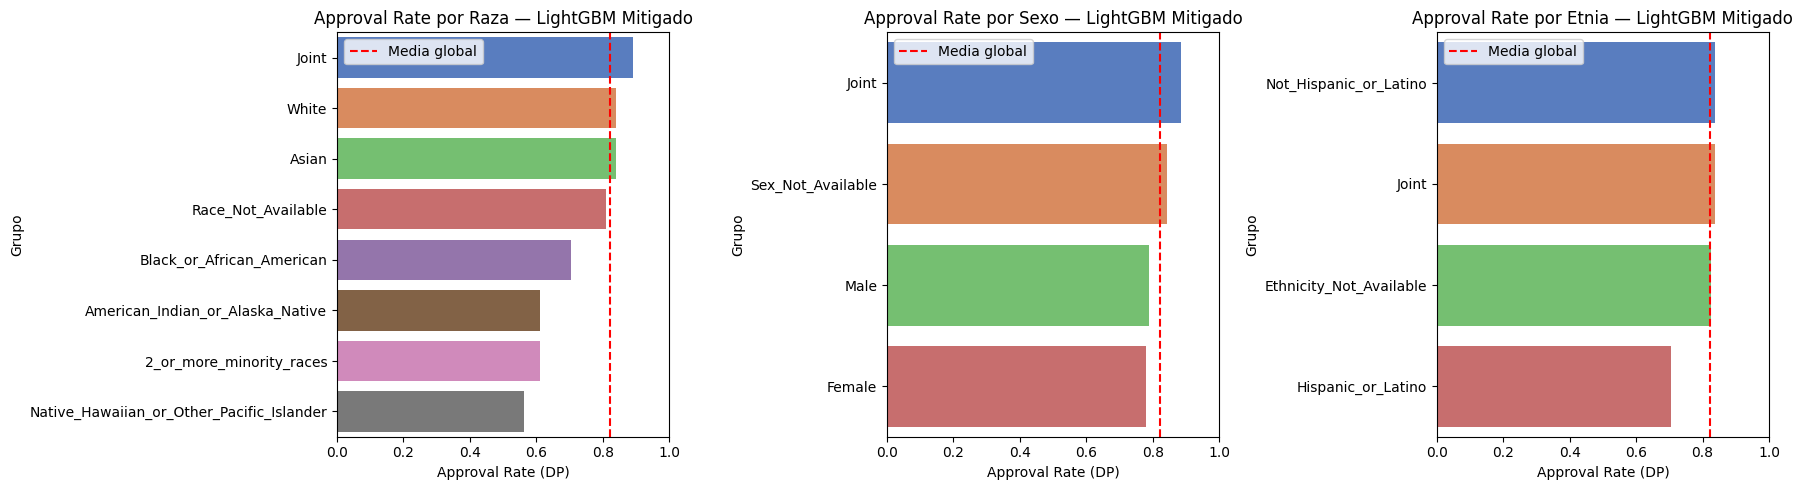

In [52]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df_group, titulo) in zip(axes, [
    (df_raza,  'Approval Rate por Raza — LightGBM Mitigado'),
    (df_sexo,  'Approval Rate por Sexo — LightGBM Mitigado'),
    (df_etnia, 'Approval Rate por Etnia — LightGBM Mitigado')
]):
    sns.barplot(data=df_group, x='Approval Rate (DP)', y='Grupo', ax=ax, palette='muted')
    ax.set_title(titulo)
    ax.set_xlim(0, 1)
    ax.axvline(x=y_pred_mitigado.mean(), color='red', linestyle='--', label='Media global')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/images/fairness_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

NO MODIFICADO:

Los gráficos confirman visualmente las disparidades detectadas en las tablas. A diferencia del Notebook 2, la media global (línea roja) se ha desplazado hacia la derecha (~0.83), lo que refleja el mayor poder predictivo de LightGBM. Sin embargo, los grupos minoritarios siguen quedando sistemáticamente por debajo de esa media, especialmente en raza, donde la distancia entre el grupo mejor y peor tratado supera los 37 puntos porcentuales. Esto evidencia que un mayor rendimiento global no implica mayor equidad.

---
### Explicabilidad — Valores SHAP

NO MODIFICADO:

Los valores SHAP (*SHapley Additive exPlanations*) permiten cuantificar la contribución de cada feature a la predicción individual del modelo. A diferencia de la importancia de features estándar, SHAP tiene en cuenta las interacciones entre variables y proporciona una explicación local (por instancia) y global (agregada). Esto es especialmente relevante en el contexto de aprobación de hipotecas, donde la ley exige poder justificar cada decisión individual.

NOTA GEMINI:

> **Nota técnica:** `TreeExplainer` falla porque el mitigador de Fairlearn no es un modelo único, sino un meta-modelo que agrupa internamente varios clasificadores LightGBM con distintos pesos.

> Por ello, no se puede auditar la "caja" entera; debemos extraer cada predictor interno, calcular su valor SHAP por separado y realizar una media ponderada.

In [56]:
# Calculamos los valores SHAP sobre una muestra de X_test para reducir tiempo
# 1000 muestras es suficiente para obtener una visión representativa
X_test_sample = X_test.sample(1000, random_state=RANDOM_STATE)

shap_values_mitigado = np.zeros(X_test_sample.shape)

# Calcular el SHAP ponderado de los sub-modelos de Fairlearn
for predictor, peso in zip(mitigador.predictors_, mitigador.weights_):
    
    explainer = shap.TreeExplainer(predictor)
    sv = explainer.shap_values(X_test_sample)
    
    # Si devuelve lista, cogemos la clase 1 (pesos de aprobación)
    if isinstance(sv, list):
        sv = sv[1]
        
    # Media ponderada según pesos
    shap_values_mitigado += sv * peso

print("Valores SHAP calculados")

Valores SHAP calculados


#### Summary plot

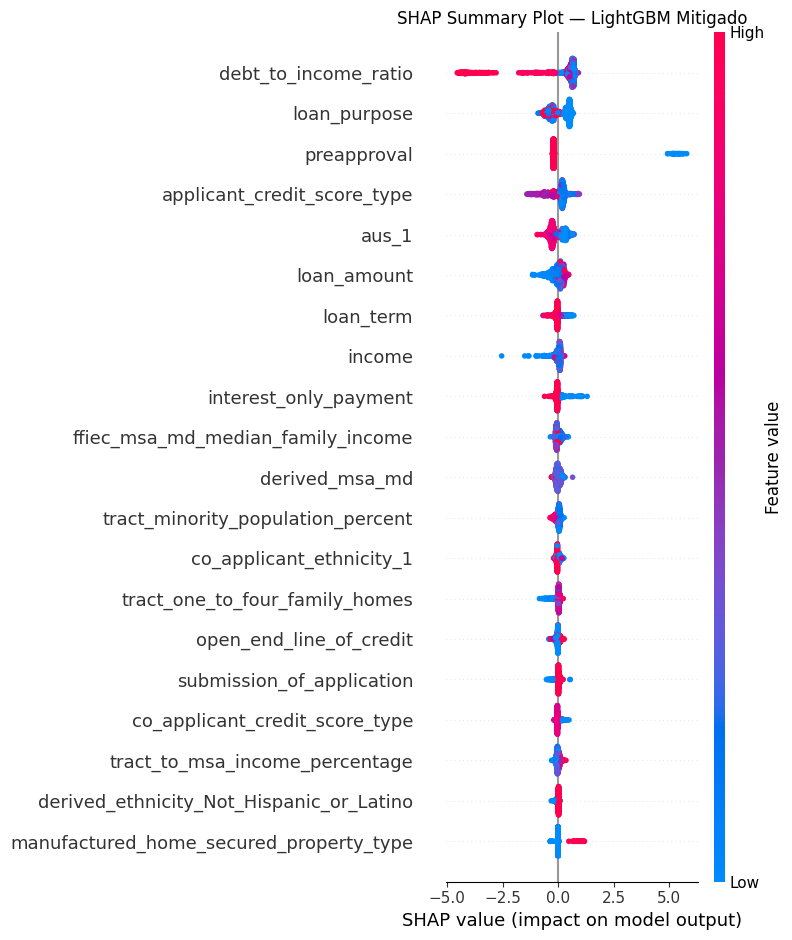

In [58]:
# Summary plot — importancia global de features
plt.figure()
shap.summary_plot(
    shap_values_mitigado, X_test_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — LightGBM Mitigado')
plt.tight_layout()
plt.savefig('../outputs/images/shap_summary_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

NO MODIFICADO:

El SHAP Summary Plot revela qué features tienen mayor impacto en las predicciones del modelo y en qué dirección. `debt_to_income_ratio` es con diferencia la feature más influyente: valores altos (en rojo) empujan fuertemente la predicción hacia la denegación (valores SHAP negativos), mientras que valores bajos favorecen la aprobación. `preapproval` destaca por su impacto positivo extremo cuando está presente, con valores SHAP de hasta +6, lo que indica que una preaprobación previa es casi determinante para la aprobación. Significativamente, `derived_race_White` aparece en la posición 8, confirmando que la raza tiene un impacto directo en las predicciones del modelo a pesar de no ser una variable financiera.

#### Bar plot

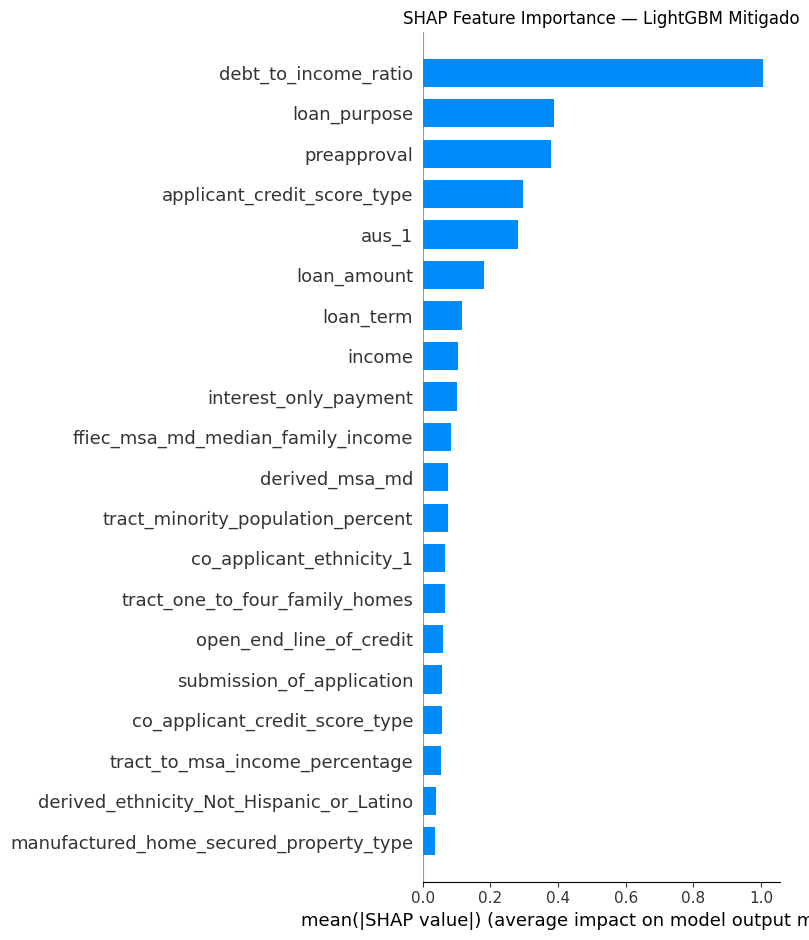

In [57]:
# Bar plot — ranking de importancia global
plt.figure()
shap.summary_plot(
    shap_values_mitigado, X_test_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — LightGBM Mitigado')
plt.tight_layout()
plt.savefig('../outputs/images/shap_bar_sesgos.png', dpi=300, bbox_inches='tight')
plt.show()

NO MODIFICADO:

El bar plot confirma el ranking de importancia global. `debt_to_income_ratio` domina claramente con un impacto medio absoluto casi cuatro veces superior al segundo clasificado. `preapproval`, `loan_purpose` y `aus_1` ocupan las siguientes posiciones, todas variables relacionadas con las características de la solicitud. La presencia de `derived_race_White` en la posición 8 y `derived_ethnicity_Not_Hispanic_or_Latino` en la posición 20 confirma que el modelo utiliza activamente información racial y étnica para tomar sus decisiones, lo que justifica la necesidad de aplicar técnicas de mitigación en el Notebook 4.

---
---

## Conclusión Final

Rendimiento vs Equidad (el trade-off central del proyecto)